# ribbon logic
### rwet final

a physical poetry generator using the class's hand-tagged semantic corpus to bias word selection by emotional temperature, extended into phrases via a markov chain built from my previous gnerative txt.

the generator refuses cold, sharp, and academic words at the point of word selection.

## corpus
my gen txt. the markov chain learns which words follow which words here.

In [1]:
CORPUS_TEXT = """
felt knit tulle conductive thread soft silicone foam velvet gel mesh industrial felt cloud fiber
stitched with running thread sealed with a slow zipper laced with ribbon logic held by snaps and patience taped with care woven in loops that remember
powered by moonlight powered by usb power powered by a warm battery powered by static powered by a dim wall outlet powered by no power at all powered by a shared charge
a keyboard that blushes when touched a screen that refuses urgency buttons that only work if you are gentle a dial that drifts like weather a touchpad made of cloth and friction a cursor that waits for your breath
people who log off early hands learning softness a shy machine spirit tired students and their prototypes a small archive of care memories that do not want to be optimized
under a desk lamp at midnight in a room where time is slower inside a tote bag by the window with quiet air in the studio after critique near a plant that survives anyway
it will not rush you it will misbehave politely it will keep your secrets imperfectly it will take breaks with you it will glow only when needed it will never ask for your attention twice
a computer of felt bound by stitched with running thread powered by moonlight with a keyboard that blushes when touched resting under a desk lamp at midnight inhabited by hands learning softness and it will not rush you
a computer of velvet bound by woven in loops that remember powered by a warm battery with a cursor that waits for your breath resting in a room where time is slower inhabited by a small archive of care and it will glow only when needed
a computer of cloud fiber bound by laced with ribbon logic powered by a shared charge with buttons that only work if you are gentle resting near a plant that survives anyway inhabited by a shy machine spirit and it will misbehave politely
soft interfaces gentle technology calm computing slow technology feminist hardware anti-optimization design textile computing e-textiles conductive thread knitting machine haptic heartbeat ambient sound warm display
the machine is soft the machine is slow the machine is patient the machine remembers gently the machine does not optimize you the machine breathes with you the machine waits the machine rests the machine glows dimly the machine holds your secrets imperfectly
felt is a material felt is a way of touching felt is a way of making felt does not fray felt absorbs felt is industrial and soft at once
the screen refuses urgency the screen is eink the screen is slow to change the screen holds what it shows the screen does not flicker the screen is paper-like the screen is calm
buttons made of neoprene buttons in lavender buttons in mint buttons in blush buttons in butter yellow buttons that snap on and off buttons that are soft to press buttons that respond slowly
a trackpad made of velostat a trackpad made of copper tape a trackpad made of cloth and friction a trackpad that modulates warmth a trackpad that reads pressure gently
the knitting machine makes patterns the knitting machine holds memory in thread the knitting machine is from 1980 the knitting machine is a computer the jacquard loom is a computer the punch card is a program the thread is data the stitch is a bit
calm technology does not demand your attention calm technology works at the periphery calm technology lets you be calm technology waits for you calm technology does not alert you calm technology is soft
i want to make computers that are soft i want to make computers that rest i want to make computers that breathe i want to make computers that hold you gently i want to make computers that do not optimize you i want to make computers that take breaks
the studio is quiet after critique the studio smells like solder and industrial felt the studio has plants that survive anyway the studio has a desk lamp the studio has a window with quiet air the studio is where i make soft things
"""

## markov chain
bigram model. learns which words follow which words in the corpus.

In [2]:
import random

words = CORPUS_TEXT.lower().split()
chain = {}
for i in range(len(words) - 1):
    w = words[i]
    n = words[i + 1]
    if w not in chain:
        chain[w] = []
    chain[w].append(n)

print(f"{len(chain)} unique words in chain")

233 unique words in chain


In [3]:
def markov_phrase(seed, length=3):
    seed = seed.lower().strip().split()[0]
    if seed not in chain:
        return seed
    result = [seed]
    current = seed
    for _ in range(length - 1):
        if current in chain and chain[current]:
            current = random.choice(chain[current]).rstrip(".,;:!?")
            result.append(current)
        else:
            break
    return " ".join(result)

## vocabulary pools
pre-computed by preprocess.py using simpleneighbors on the class's hand-tagged semantic corpus.
each slot has word lists for three temperatures: COOL, NEUTRAL, WARM.
the generator refuses cold, sharp, and academic words at the preprocess stage.

In [4]:
POOLS = {
    "COOL": {
        "material":   ['necessity', 'horse', 'threads', 'flute-player', 'period', 'lion', 'flutter', 'men singers', 'posts', 'gas', 'trace', 'chestnut', 'tall', 'glass', 'joint', 'wood', 'woman', 'plants', 'animals', 'gowns'],
        "structure":  ['camera', 'motion', 'stamp', 'return', 'cross-lights', 'sidewalk', 'days', 'follows', 'clock', 'mouth', 'medicine-tubes', 'show', 'buttons', 'lamp', 'character', 'loop', 'again', 'ball', 'something', 'mutual'],
        "power":      ['inherent', 'gasoline', 'normal', 'leaves', 'your knees', 'wood', 'woman', 'plants', 'sand', 'whiskers', 'period', 'horse', 'posts', 'threads', 'flute-player', 'flutter', 'glass', 'trace', 'gas', 'men singers'],
        "interface":  ['platform', 'set', 'heights', 'rooms', 'bottle', 'writers', 'ground', 'topmost', 'store', 'turnpikes', 'furniture', 'instruments', 'physical', 'captain', 'proficient', 'trip', 'bearer', 'traces', 'the pilot', 'temples'],
        "location":   ['swiftness', 'rippling', 'nose', 'four', 'larger', 'centre', 'show', 'mutual', 'lyric', 'loop', 'again', 'something', 'character', 'whole', 'message', 'all', 'worlds', 'rocks', 'ears', 'close'],
        "inhabitant": ['lust', 'humanity', 'nothing', 'instinct', 'pride', 'personality', 'soul', 'tears', 'artistic', 'forgivable', 'ashamed', 'humble', 'sorrow', 'salutation', 'support', 'daily', 'disappointment', 'passion', 'wanting'],
        "promise":    ['fame', 'near', 'foolish', 'ok', 'jolly', 'girlish', 'functionless', 'slang', 'mean', 'imagination', 'charming', 'vibe', 'strong', 'performances', 'pride', 'personality', 'beautiful', 'comic', 'merry'],
    },
    "NEUTRAL": {
        "material":   ['bodies', 'fields', 'animals', 'plants', 'sand', 'mother', 'cloth', 'harvest', 'candle', 'tails', 'arm', 'dog', 'woman', 'animal', 'taxi drivers', 'herb', 'taint', 'babies', 'tree', 'carpets'],
        "structure":  ['okay', 'harmonious', 'salon', 'lamp', 'loop', 'mutual', 'something', 'character', 'lyric', 'again', 'message', 'all', 'whispers', 'ease', 'breast', 'broad', 'open', 'full', 'close', 'show'],
        "power":      ['temperate', 'yellow', 'simmering', 'sunset', 'red', 'bath', 'praise', 'middle', 'notions', 'lift', 'fire', 'vineyards', 'heat', 'summer', 'afternoon', 'glow', 'asleep', 'sunlight', 'honest', 'manner'],
        "interface":  ['lap', 'gifts', 'couch', 'mattress', 'tom', 'part', 'radiators', 'tavern', 'taxi drivers', 'houses', 'shirt', 'figure', 'bearer', 'dessert', 'stocking', 'physical', 'rooms', 'instruments', 'proficient', 'furniture'],
        "location":   ['okay', 'harmonious', 'ease', 'whispers', 'breast', 'salon', 'kiln', 'lamp', 'coats', 'songs', 'fond', 'nod', 'foulness', 'lovely', 'rich', 'house', 'shaft', 'together', 'everyone', 'unusually good'],
        "inhabitant": ['melancholies', 'husband', 'personal', 'concerns', 'wives', 'peculiar', 'front', 'faithful', 'lonely', 'romance', 'wanting', 'interest', 'you', 'ordinary', 'daily', 'amazing', 'problems', 'confused', 'conceit', 'salutation'],
        "promise":    ['true loves', 'comic', 'sentimental', 'merry', 'enchanted', 'funny', 'friendship', 'childhood', 'fairness', 'raillery', 'cheerful', 'beautiful', 'sincere', 'affection', 'forgivable', 'fancies', 'talks', 'great', 'enthusiast', 'mirth'],
    },
    "WARM": {
        "material":   ['sunlight', 'heat', 'vineyards', 'summer', 'day', 'living', 'hand', 'trees', 'fire', 'honey', 'glow', 'garden', 'plenty', 'taint', 'herb', 'alive', 'laughter', 'loaf', 'red', 'tails'],
        "structure":  ['okay', 'harmonious', 'close', 'full', 'breast', 'whispers', 'ease', 'salon', 'lamp', 'worlds', 'belly', 'rippling', 'swiftness', 'coats', 'hearts', 'bird', 'open', 'broad', 'bosom', 'aura'],
        "power":      ['tender', 'father', 'beloved', 'honest', 'share', 'manner', 'asleep', 'patience', 'pleased', 'music', 'loveliest', 'effeminate', 'home', 'emotion', 'awesome', 'happiness', 'everywhere', 'joy', 'sentiment', 'tale'],
        "interface":  ['guest', 'sheik', 'lips', 'pet', 'mattress', 'part', 'radiators', 'tavern', 'tom', 'lap', 'hearth-brush', 'presents', 'gifts', 'village', 'hearthrug', 'dinner', 'touch', 'parent', 'bedroom', 'diary'],
        "location":   ['whispers', 'ease', 'harmonious', 'okay', 'nod', 'foulness', 'songs', 'unusually good', 'fond', 'lovely', 'rich', 'everyone', 'aura', 'kind', 'love', 'asleep', 'breast', 'kiln', 'salon', 'sleep'],
        "inhabitant": ['enchanted', 'funny', 'true loves', 'comic', 'merry', 'sentimental', 'friendship', 'fairness', 'mirth', 'sincere', 'affection', 'concerns', 'dear', 'husband', 'melancholies', 'personal', 'nice', 'home', 'patience', 'effeminate'],
        "promise":    ['comic', 'funny', 'enchanted', 'merry', 'sentimental', 'true loves', 'childhood', 'raillery', 'cheerful', 'beautiful', 'beauty', 'fame', 'near', 'charming', 'vibe', 'girlish', 'slang', 'foolish', 'jolly', 'functionless'],
    },
}

In [5]:
def pick_seed(temp, slot_name):
    pool = POOLS[temp][slot_name]
    word = random.choice(pool) if pool else "soft"
    return word.split()[0]

def slot(temp, slot_name, length=3):
    seed = pick_seed(temp, slot_name)
    return markov_phrase(seed, length)

## poem forms

In [6]:
def poem_stanza(temp):
    m  = slot(temp, "material", 2)
    s  = slot(temp, "structure", 3)
    p  = slot(temp, "power", 3)
    i  = slot(temp, "interface", 3)
    l  = slot(temp, "location", 3)
    n  = slot(temp, "inhabitant", 3)
    pr = slot(temp, "promise", 3)
    lines = [
        f"a computer of {m}",
        f"  bound by {s}",
        f"    powered by {p}",
        f"      with {i}",
        f"        resting among {l}",
        f"          inhabited by {n}",
        f"            and it offers {pr}",
    ]
    return "\n".join(lines)

def poem_circle(temp):
    slots = ["material", "structure", "power", "interface", "location", "inhabitant", "promise"]
    words = [pick_seed(temp, s) for s in slots]
    center = slot(temp, "material", 2)
    return f"[ {' / '.join(words)} ]\n\na computer of {center}"

def poem_concrete(temp):
    m  = pick_seed(temp, "material")
    s  = pick_seed(temp, "structure")
    p  = pick_seed(temp, "power")
    i  = pick_seed(temp, "interface")
    l  = pick_seed(temp, "location")
    n  = pick_seed(temp, "inhabitant")
    pr = pick_seed(temp, "promise")
    lines = [
        f"a computer of {m}",
        f"   {s}",
        f"      {p}",
        f"         {i}",
        f"      {l}",
        f"   {n}",
        f"{pr}",
    ]
    return "\n".join(lines)


## generate poems

In [7]:
for temp in ["COOL", "NEUTRAL", "WARM"]:
    # print(f"temperature: {temp.lower()}")
    print(poem_stanza(temp))
    print()

a computer of chestnut
  bound by days
    powered by period
      with turnpikes
        resting among all powered by
          inhabited by humble
            and it offers girlish

a computer of harvest
  bound by open
    powered by red
      with instruments
        resting among rich
          inhabited by conceit
            and it offers sentimental

a computer of garden
  bound by aura
    powered by loveliest
      with pet
        resting among everyone
          inhabited by husband
            and it offers slang



In [8]:
print("temperature: warm")
print(poem_circle("WARM"))

temperature: warm
[ day / swiftness / father / hearthrug / lovely / comic / cheerful ]

a computer of alive


In [12]:
temps = ["COOL", "NEUTRAL", "WARM"]
forms = [poem_stanza, poem_circle, poem_concrete]

for _ in range(5):
    temp = random.choice(temps)
    form = random.choice(forms)
    # print(f"temp: {temp.lower()}")
    print(form(temp))
    print()


[ laughter / open / father / dinner / asleep / nice / charming ]

a computer of day

a computer of taint
   open
      father
         guest
      salon
   funny
merry

a computer of woman
   close
      middle
         figure
      salon
   wives
great

[ woman / all / glow / bearer / okay / wanting / beautiful ]

a computer of plants that

[ summer / okay / effeminate / part / salon / mirth / beauty ]

a computer of laughter



## concrete form
diamond shape using typographic spacing. widens outward then narrows back.

In [10]:
for temp in ["COOL", "NEUTRAL", "WARM"]:
    print(f"temperature: {temp.lower()}")
    print(poem_concrete(temp))
    print()


temperature: cool
a computer of flute-player
   again
      threads
         the
      loop
   lust
strong

temperature: neutral
a computer of bodies
   breast
      praise
         stocking
      salon
   you
fancies

temperature: warm
a computer of hand
   ease
      home
         lap
      aura
   enchanted
funny



## spiral form
inspired by allison parrish's word gan rose. words spiral outward from center, rotating to follow the curve, sizing up toward the edge. rendered with matplotlib.

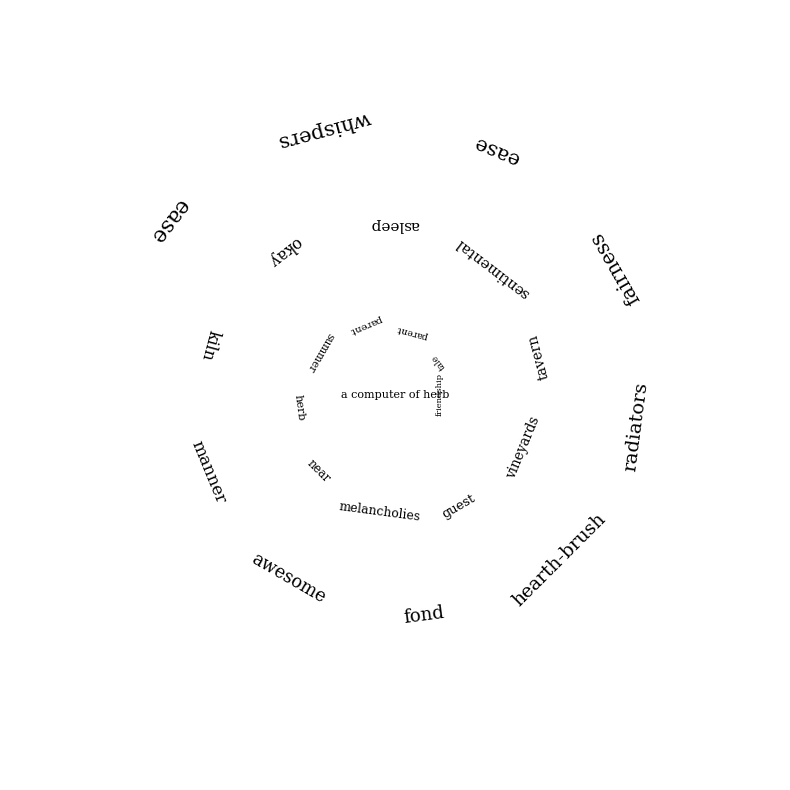

In [11]:
import matplotlib.pyplot as plt
import math

def poem_spiral(temp, n_words=24):
    slots = ["material", "structure", "power", "interface", "location", "inhabitant", "promise"]
    words = [pick_seed(temp, random.choice(slots)) for _ in range(n_words)]
    center = slot(temp, "material", 2)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.axis("off")
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    for i, word in enumerate(words):
        t = i / n_words
        r = 0.15 + 0.85 * t
        angle_deg = i * (360 / n_words) * 2.5
        angle_rad = math.radians(angle_deg)
        x = r * math.cos(angle_rad)
        y = r * math.sin(angle_rad)
        fontsize = 6 + 10 * t
        rotation = angle_deg + 90
        ax.text(x, y, word,
                fontsize=fontsize,
                rotation=rotation,
                rotation_mode="anchor",
                ha="center",
                va="center",
                color="black",
                fontfamily="serif")

    ax.text(0, 0, f"a computer of {center}",
            fontsize=8, ha="center", va="center",
            color="black", fontfamily="serif",
            multialignment="center")

    plt.tight_layout()
    plt.show()

poem_spiral("WARM")
